In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

# Load all images from data/ (supports png/jpg/jpeg)
data_dir = Path("../data")
image_paths = sorted(
    [*data_dir.glob("*.png"), *data_dir.glob("*.jpg"), *data_dir.glob("*.jpeg")]
)

if not image_paths:
    raise FileNotFoundError("No images found in ../data")

print("Images found:")
for i, p in enumerate(image_paths):
    print(f"[{i}] {p.name}")

# Initialize PaddleOCR once (RU model usually handles Latin letters too)
ocr = PaddleOCR(use_angle_cls=True, lang="ru")
print("\nPaddleOCR initialized.")

c:\Users\tzyki\Documents\Work\docs_ocr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


Images found:
[0] test3.png
[1] test4.jpg
[2] test5.jpg


C:\Users\tzyki\AppData\Local\Temp\ipykernel_17788\175857454.py:20: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang="ru")
c:\Users\tzyki\Documents\Work\docs_ocr\.venv\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `C:\Users\tzyki\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
[2026-04-15 20:16:47,929] [    INFO] _client.py:1025 - HTTP Request: GET https://huggingface.co/api/models/PaddlePaddle/PP-LCNet_x1_0_doc_ori/revision/main "HTTP/1.1


PaddleOCR initialized.


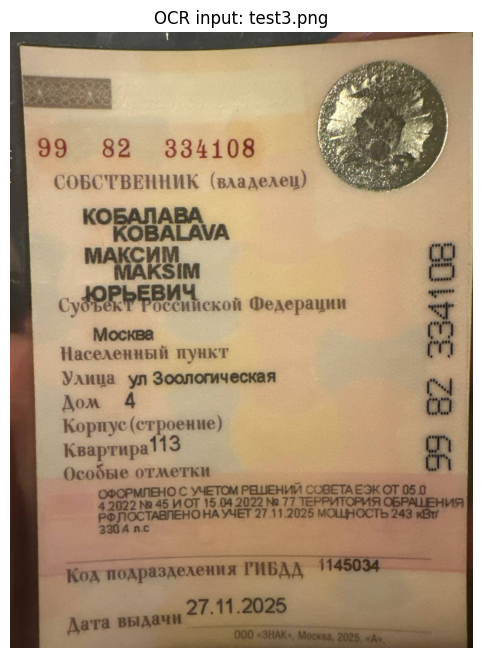

C:\Users\tzyki\AppData\Local\Temp\ipykernel_17788\3312117672.py:14: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(str(image_path), cls=True)


TypeError: PaddleOCR.predict() got an unexpected keyword argument 'cls'

In [ ]:
# Pick an image index from the printed list above
image_index = 0
image_path = image_paths[image_index]

# Visual check
img = plt.imread(image_path)
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title(f"OCR input: {image_path.name}")
plt.show()

# Run PaddleOCR and print text lines
result = ocr.predict(str(image_path))

print(f"Extracted text from {image_path.name}:\n")
if not result or not result[0]:
    print("(No text detected)")
else:
    for i, line in enumerate(result[0], start=1):
        text = line[1][0]
        score = line[1][1]
        print(f"{i:02d}. {text} (conf: {score:.3f})")